# Part 1 – Grid Integration of Offshore Wind [13 pts]
OE44170 Offshore Renewable Technologies – Assignment: Electrical Aspects

This notebook supports the answers of Part 1. It uses the tab **`WTG Yield Wake`** of the provided Excel
template (20 MW WTG, 280 m rotor, 160 m hub height, wind park of 80 WTGs) to

1. reproduce the power curve, thrust curve and the five operational areas I–V,
2. quantify the power-balance challenges of areas I, III and V (incl. a hard cut-out comparison),
3. analyse the omni-directional wake effect (park efficiency) per wind speed,
4. compare a large and a smaller rotor for the same 20 MW generator.

Figures are saved to `report/figures/` for the LaTeX report.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

XLSX = Path("data/ORT_Assignment_Wind_Electrical.xlsx")
FIG = Path("report/figures/electrical"); FIG.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 200, "font.size": 10,
                     "axes.grid": True, "grid.alpha": 0.3})

RHO = 1.224        # air density used in the Excel template [kg/m^3]
H_YEAR_XLS = 8766  # hours per year used in the Excel template (365.25 d)

## 1. Load the template data (tab `WTG Yield Wake`)
The input columns are read directly from the Excel file; the formula columns (power in the wind, $C_P$,
gross yield, yield incl. wake) are recomputed here with exactly the same formulas as the template.

In [2]:
raw = pd.read_excel(XLSX, sheet_name="WTG Yield Wake", header=None)
D_rotor = float(raw.iloc[2, 3])     # D3  rotor diameter [m]
P_rated = float(raw.iloc[4, 3])     # D5  rated power [MW]
rpm     = float(raw.iloc[6, 3])     # D7  rated rotor speed [rpm]
hub     = float(raw.iloc[8, 3])     # D9  hub height [m]
N_WTG   = int(raw.iloc[10, 10])     # K11 number of WTGs

df = raw.iloc[13:42, [7, 3, 5, 8, 10]].copy()
df.columns = ["v", "P_wtg", "Ct", "time_pct", "park_eff"]
df = df.astype(float).fillna(0.0).reset_index(drop=True)
df.loc[df["v"] < 3, "park_eff"] = 0.0          # no production below cut-in

A = np.pi * D_rotor**2 / 4
df["P_wind"] = 0.5 * RHO * A * df["v"]**3 / 1e6                         # MW
df["Cp"] = np.where(df["P_wind"] > 0, df["P_wtg"] / df["P_wind"], 0)
df["hours"] = df["time_pct"] / 100 * H_YEAR_XLS
df["E_wtg"] = df["hours"] * df["P_wtg"]                                  # MWh/yr, single WTG
df["E_park"] = N_WTG * df["E_wtg"] * df["park_eff"]                      # MWh/yr, park incl. wake

print(f"Rotor diameter {D_rotor:.0f} m | swept area {A:,.0f} m2 | rated {P_rated:.0f} MW")
print(f"Specific rating (power density rotor): {P_rated*1e6/A:.0f} W/m2")
print(f"Rated tip speed: {np.pi*D_rotor*rpm/60:.1f} m/s | hub height {hub:.0f} m | {N_WTG} WTGs")
E_wtg, E_park = df["E_wtg"].sum(), df["E_park"].sum()
print(f"\nGross yield single WTG : {E_wtg:,.0f} MWh/yr  (CF = {E_wtg/P_rated/8760:.1%})")
print(f"Park yield incl. wake  : {E_park:,.0f} MWh/yr  (CF = {E_park/P_rated/8760/N_WTG:.1%})")
print(f"Overall park efficiency: {E_park/(N_WTG*E_wtg):.1%}  -> wake loss {1-E_park/(N_WTG*E_wtg):.1%}")
df.round(3)

Rotor diameter 280 m | swept area 61,575 m2 | rated 20 MW
Specific rating (power density rotor): 325 W/m2
Rated tip speed: 102.6 m/s | hub height 160 m | 80 WTGs

Gross yield single WTG : 98,815 MWh/yr  (CF = 56.4%)
Park yield incl. wake  : 6,502,785 MWh/yr  (CF = 46.4%)
Overall park efficiency: 82.3%  -> wake loss 17.7%


/opt/anaconda3/lib/python3.13/site-packages/openpyxl/worksheet/_read_only.py:85: UserWarning: Unknown extension is not supported and will be removed
  for idx, row in parser.parse():


,v,P_wtg,Ct,time_pct,park_eff,P_wind,Cp,hours,E_wtg,E_park
0,0.5,0.000,0.000,0.652,0.000,0.005,0.000,57.154,0.000,0.000
1,1.5,0.000,0.000,1.735,0.000,0.127,0.000,152.090,0.000,0.000
2,2.5,0.000,0.000,3.356,0.000,0.589,0.000,294.187,0.000,0.000
3,3.5,0.437,0.855,4.832,0.489,1.616,0.270,423.573,185.101,7246.525
4,4.5,1.423,0.855,6.390,0.567,3.434,0.414,560.147,797.090,36132.969
5,5.5,2.830,0.855,7.657,0.616,6.270,0.451,671.213,1899.532,93659.228
6,6.5,4.772,0.858,8.732,0.637,10.349,0.461,765.447,3652.714,186041.206
7,7.5,7.460,0.863,9.448,0.646,15.898,0.469,828.212,6178.459,319182.873
8,8.5,10.949,0.840,9.619,0.662,23.143,0.473,843.202,9232.214,488953.476
9,9.5,14.623,0.752,9.123,0.699,32.309,0.453,799.722,11694.337,653553.437


## 2. Power curve, thrust curve and operational areas I–V
Area boundaries are taken from the template data and the figure in the assignment:

| Area | Wind speed | Control | Characteristic |
|---|---|---|---|
| I   | < 3 m/s      | – | below cut-in, no production |
| II  | 3 – 8 m/s    | variable RPM, fixed pitch | $C_T$ ≈ 0.86 constant, $P \propto v^3$ |
| III | 8 – 14 m/s   | variable pitch, fixed RPM | steepest part of power curve, $C_T$ drops |
| IV  | 14 – 22.5 m/s | fixed RPM, rated power | $P = P_{rated}$ |
| V   | 22.5 – 28 m/s | high-wind ride-through | power ramps down linearly to 0 at 28 m/s |

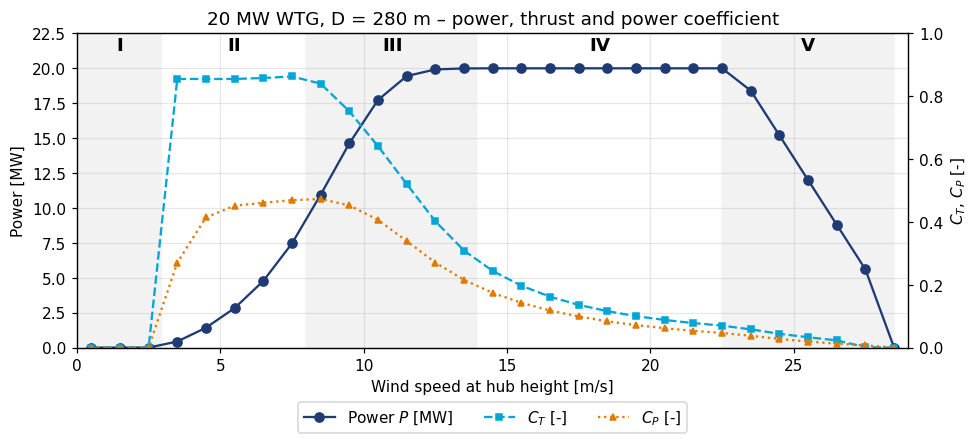

In [3]:
areas = [("I", 0, 3), ("II", 3, 8), ("III", 8, 14), ("IV", 14, 22.5), ("V", 22.5, 28.5)]
shade = ["#f2f2f2", "#ffffff", "#f2f2f2", "#ffffff", "#f2f2f2"]

fig, ax = plt.subplots(figsize=(9, 4.2))
for (name, a, b), c in zip(areas, shade):
    ax.axvspan(a, b, color=c, zorder=0)
    ax.text((a + b) / 2, 21.3, name, ha="center", fontsize=12, fontweight="bold")
ax.plot(df["v"], df["P_wtg"], "o-", color="#1f3b73", label="Power $P$ [MW]")
ax.set_xlabel("Wind speed at hub height [m/s]"); ax.set_ylabel("Power [MW]")
ax.set_ylim(0, 22.5); ax.set_xlim(0, 29)
ax2 = ax.twinx()
ax2.plot(df["v"], df["Ct"], "s--", color="#00a6d6", ms=4, label="$C_T$ [-]")
ax2.plot(df["v"], df["Cp"], "^:", color="#e07b00", ms=4, label="$C_P$ [-]")
ax2.set_ylabel("$C_T$, $C_P$ [-]"); ax2.set_ylim(0, 1.0); ax2.grid(False)
h1, l1 = ax.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=3)
ax.set_title(f"{P_rated:.0f} MW WTG, D = {D_rotor:.0f} m – power, thrust and power coefficient")
fig.tight_layout(); fig.savefig(FIG / "p1_power_thrust_areas.png"); plt.show()

## 3. Area I – what does it mean for the power balance?
Below cut-in the WTG produces nothing. The time share in area I and the number of "crossings" of the
cut-in speed indicate how often the full output disappears/reappears and must be covered by other units.

In [4]:
in_area = lambda a, b: (df["v"] >= a) & (df["v"] < b)
summary = []
for name, a, b in areas:
    m = in_area(a, b)
    summary.append({"Area": name, "v range [m/s]": f"{a}-{b}",
                    "time share [%]": df.loc[m, "time_pct"].sum(),
                    "hours/yr": df.loc[m, "hours"].sum(),
                    "share of WTG energy [%]": 100 * df.loc[m, "E_wtg"].sum() / E_wtg})
summary = pd.DataFrame(summary).round(1)
summary

,Area,v range [m/s],time share [%],hours/yr,share of WTG energy [%]
0,I,0-3,5.7,503.4,0.0
1,II,3-8,37.1,3248.6,12.9
2,III,8-14,44.4,3892.0,64.7
3,IV,14-22.5,12.1,1057.2,21.4
4,V,22.5-28.5,0.7,63.2,1.1


## 4. Area III – sensitivity of power to wind speed
The slope $dP/dv$ of the power curve determines how much a wind-speed fluctuation or a wind **forecast
error** translates into a power imbalance. Area III is where this slope is largest.

Max WTG slope: 3.67 MW per m/s at ~9.0 m/s (18% of rated per m/s)
Park (80 WTGs, incl. wake) max slope: 255 MW per m/s = 16% of installed capacity per m/s


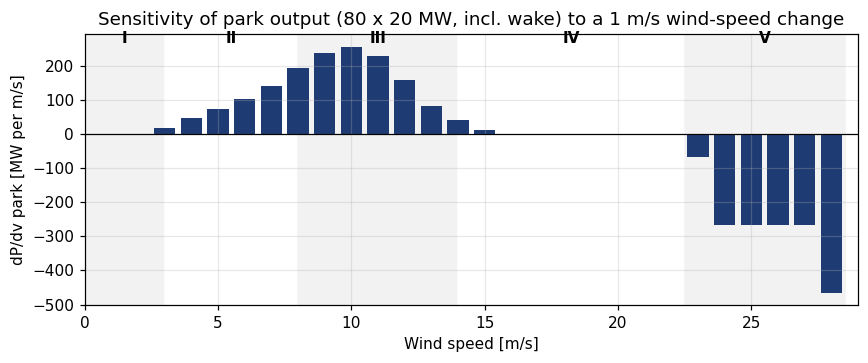

,v_mid,dP/dv WTG [MW/(m/s)],dP/dv park [MW/(m/s)]
0,1.0,0.00,0.00
1,2.0,0.00,0.00
2,3.0,0.44,17.11
3,4.0,0.99,47.40
4,5.0,1.41,75.03
5,6.0,1.94,103.51
6,7.0,2.69,142.34
7,8.0,3.49,194.49
8,9.0,3.67,237.35
9,10.0,3.11,255.39


In [5]:
v_mid = 0.5 * (df["v"].values[1:] + df["v"].values[:-1])
dPdv = np.diff(df["P_wtg"].values) / np.diff(df["v"].values)               # MW per m/s, one WTG
dPdv_park = np.diff((df["P_wtg"] * df["park_eff"]).values) * N_WTG          # MW per m/s, park incl. wake
sens = pd.DataFrame({"v_mid": v_mid, "dP/dv WTG [MW/(m/s)]": dPdv,
                     "dP/dv park [MW/(m/s)]": dPdv_park}).round(2)
i_max = sens["dP/dv WTG [MW/(m/s)]"].idxmax()
print(f"Max WTG slope: {dPdv[i_max]:.2f} MW per m/s at ~{v_mid[i_max]} m/s "
      f"({dPdv[i_max]/P_rated:.0%} of rated per m/s)")
print(f"Park (80 WTGs, incl. wake) max slope: {dPdv_park.max():.0f} MW per m/s "
      f"= {dPdv_park.max()/(N_WTG*P_rated):.0%} of installed capacity per m/s")

fig, ax = plt.subplots(figsize=(8, 3.4))
for (name, a, b), c in zip(areas, shade):
    ax.axvspan(a, b, color=c, zorder=0); ax.text((a+b)/2, dPdv_park.max()*1.05, name, ha="center", fontweight="bold")
ax.bar(v_mid, dPdv_park, width=0.8, color="#1f3b73")
ax.axhline(0, color="k", lw=0.8)
ax.set_xlabel("Wind speed [m/s]"); ax.set_ylabel("dP/dv park [MW per m/s]")
ax.set_title("Sensitivity of park output (80 x 20 MW, incl. wake) to a 1 m/s wind-speed change")
ax.set_xlim(0, 29); ax.set_ylim(top=dPdv_park.max()*1.15)
fig.tight_layout(); fig.savefig(FIG / "p1_sensitivity_dPdv.png"); plt.show()
sens

## 5. Area V (high-wind ride-through) versus a "hard cut-out" (25 m/s, restart at 22 m/s)
A synthetic storm passage (wind speed rising to ~28 m/s and decaying again, with turbulence and
spatial differences between the 80 WTGs) is fed into both control strategies:

* **HWRT (area V):** the template power curve, linear ramp-down between 22.5 and 28 m/s.
* **Hard cut-out:** rated power up to 25 m/s, stop above 25 m/s, restart only below 22 m/s (hysteresis).

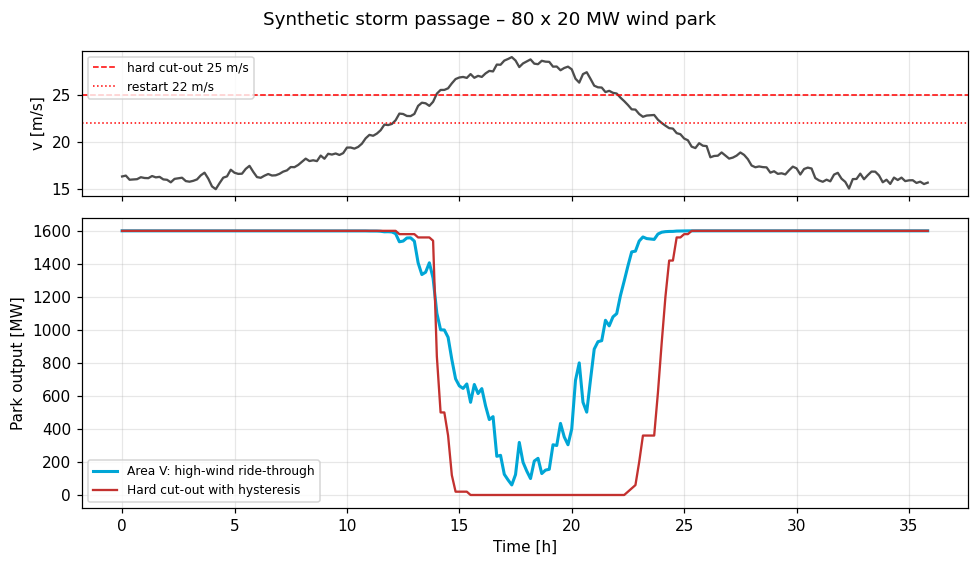

Largest 10-min ramp  HWRT:    294 MW | hard cut-out:    700 MW
Energy during storm  HWRT:  48436 MWh | hard cut-out:  42083 MWh

Annual yield one WTG – HWRT: 98,815 MWh | hard cut-out (no hysteresis): 98,768 MWh (+47 MWh)


In [6]:
rng = np.random.default_rng(1)
t = np.arange(0, 36, 1/6)                                    # 36 h in 10-min steps
v_storm = 16 + 12.5 * np.exp(-((t - 18) / 7) ** 2)           # storm envelope
v_storm = v_storm + np.convolve(rng.normal(0, 0.8, t.size), np.ones(3)/3, mode="same")
offsets = rng.normal(0, 0.8, N_WTG)                          # spatial differences between WTGs

v_pc = np.r_[0, df["v"].values]; p_pc = np.r_[0, df["P_wtg"].values]
def p_hwrt(v):
    return np.interp(v, v_pc, p_pc, right=0.0)

def p_hard(v_series):
    on, out = True, np.zeros_like(v_series)
    for k, v in enumerate(v_series):
        if on and v > 25: on = False
        elif (not on) and v < 22: on = True
        out[k] = np.interp(min(v, 14.5), v_pc, p_pc) if (on and v <= 25) else 0.0
    return out

P_soft = np.zeros_like(t); P_hard = np.zeros_like(t)
for o in offsets:
    vs = v_storm + o
    P_soft += p_hwrt(vs); P_hard += p_hard(vs)

fig, ax = plt.subplots(2, 1, figsize=(9, 5.2), sharex=True, gridspec_kw={"height_ratios": [1, 2]})
ax[0].plot(t, v_storm, color="0.3"); ax[0].axhline(25, ls="--", color="r", lw=1, label="hard cut-out 25 m/s")
ax[0].axhline(22, ls=":", color="r", lw=1, label="restart 22 m/s"); ax[0].set_ylabel("v [m/s]"); ax[0].legend(loc="upper left", fontsize=8)
ax[1].plot(t, P_soft, color="#00a6d6", lw=2, label="Area V: high-wind ride-through")
ax[1].plot(t, P_hard, color="#c3312f", lw=1.5, label="Hard cut-out with hysteresis")
ax[1].set_ylabel("Park output [MW]"); ax[1].set_xlabel("Time [h]"); ax[1].legend(loc="lower left", fontsize=8)
fig.suptitle("Synthetic storm passage – 80 x 20 MW wind park"); fig.tight_layout()
fig.savefig(FIG / "p1_storm_hwrt_vs_hardcutout.png"); plt.show()

ramp_soft = np.abs(np.diff(P_soft)).max(); ramp_hard = np.abs(np.diff(P_hard)).max()
print(f"Largest 10-min ramp  HWRT: {ramp_soft:6.0f} MW | hard cut-out: {ramp_hard:6.0f} MW")
print(f"Energy during storm  HWRT: {P_soft.sum()/6:6.0f} MWh | hard cut-out: {P_hard.sum()/6:6.0f} MWh")

# annual energy effect for one WTG (bin method, hysteresis ignored -> optimistic for hard cut-out)
hard_curve = np.select([df["v"] < 22.5, df["v"] <= 25], [df["P_wtg"], P_rated], default=0.0)
E_hard = (df["hours"] * hard_curve).sum()
print(f"\nAnnual yield one WTG – HWRT: {E_wtg:,.0f} MWh | hard cut-out (no hysteresis): {E_hard:,.0f} MWh "
      f"({E_wtg-E_hard:+,.0f} MWh)")

## 6. Wake effects – park efficiency versus wind speed and thrust coefficient
The park efficiency per wind speed bin (column K of the template) is plotted together with $C_T$.
Wake effects are considered *negligible* when the park efficiency is ≥ 99 %.

Wind speeds with park efficiency >= 99 % (negligible wake): 14.5 – 22.5 m/s
   v    Ct  park_eff  wake_loss_pct
 3.5 0.855     0.489         51.064
 4.5 0.855     0.567         43.336
 5.5 0.855     0.616         38.367
 6.5 0.858     0.637         36.335
 7.5 0.863     0.646         35.424
 8.5 0.840     0.662         33.798
 9.5 0.752     0.699         30.142
10.5 0.641     0.756         24.379
11.5 0.521     0.838         16.232
12.5 0.402     0.918          8.212
13.5 0.309     0.967          3.339
14.5 0.244     0.992          0.823
15.5 0.197     0.999          0.057
16.5 0.162     0.999          0.057
17.5 0.136     0.999          0.057
18.5 0.116     0.999          0.057
19.5 0.100     0.999          0.057
20.5 0.088     0.999          0.057
21.5 0.078     0.999          0.057
22.5 0.070     0.999          0.057
23.5 0.058     1.040         -4.000
24.5 0.044     1.040         -4.000
25.5 0.033     1.040         -4.000
26.5 0.023     1.040         -4.000
27.5 0.002     1.040    

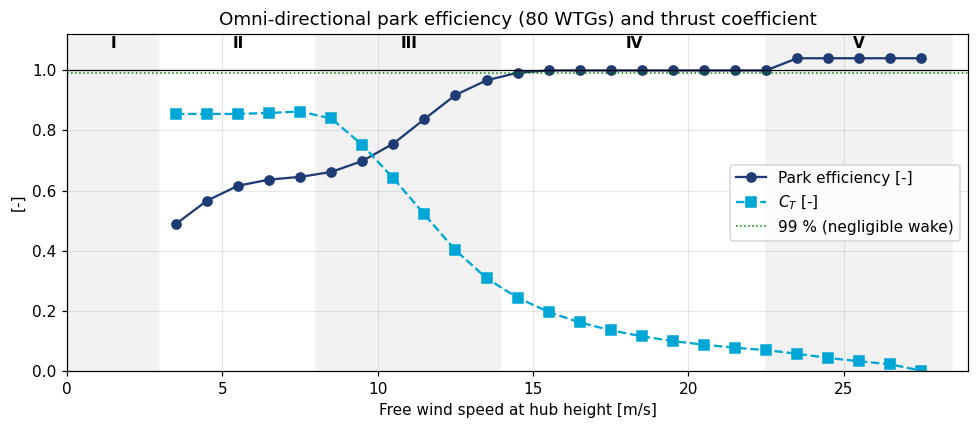

In [7]:
prod = df[df["park_eff"] > 0]
negl = prod[prod["park_eff"] >= 0.99]
print("Wind speeds with park efficiency >= 99 % (negligible wake):",
      f"{negl['v'].min()} – {negl[negl['park_eff'] < 1.0]['v'].max()} m/s")
print(prod[["v", "Ct", "park_eff"]].assign(wake_loss_pct=lambda d: 100*(1-d.park_eff)).round(3).to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4))
for (name, a, b), c in zip(areas, shade):
    ax.axvspan(a, b, color=c, zorder=0); ax.text((a+b)/2, 1.075, name, ha="center", fontweight="bold")
ax.plot(prod["v"], prod["park_eff"], "o-", color="#1f3b73", label="Park efficiency [-]")
ax.plot(prod["v"], prod["Ct"], "s--", color="#00a6d6", label="$C_T$ [-]")
ax.axhline(1.0, color="k", lw=0.8); ax.axhline(0.99, color="g", ls=":", lw=1, label="99 % (negligible wake)")
ax.set_xlim(0, 29); ax.set_ylim(0, 1.12); ax.set_xlabel("Free wind speed at hub height [m/s]")
ax.set_ylabel("[-]"); ax.legend(loc="center right")
ax.set_title(f"Omni-directional park efficiency ({N_WTG} WTGs) and thrust coefficient")
fig.tight_layout(); fig.savefig(FIG / "p1_park_efficiency_ct.png"); plt.show()

### Wake loss per area (energy)

In [8]:
rows = []
for name, a, b in areas:
    m = in_area(a, b)
    gross = N_WTG * df.loc[m, "E_wtg"].sum(); net = df.loc[m, "E_park"].sum()
    rows.append({"Area": name, "gross [GWh/yr]": gross/1e3, "net incl. wake [GWh/yr]": net/1e3,
                 "wake loss [GWh/yr]": (gross-net)/1e3,
                 "share of total wake loss [%]": np.nan})
wl = pd.DataFrame(rows); wl["share of total wake loss [%]"] = 100*wl["wake loss [GWh/yr]"]/wl["wake loss [GWh/yr]"].sum()
wl.round(1)

,Area,gross [GWh/yr],net incl. wake [GWh/yr],wake loss [GWh/yr],share of total wake loss [%]
0,I,0.0,0.0,0.0,0.0
1,II,1017.0,642.3,374.8,26.7
2,III,5111.0,4086.2,1024.8,73.1
3,IV,1691.5,1686.9,4.6,0.3
4,V,85.7,87.4,-1.8,-0.1


### Why the park produces *more* than 80 × single WTG at 23.5–27.5 m/s
In area V the power curve has a **negative** slope. A downstream WTG sees a reduced wind speed and therefore
operates at a higher point of the ramp-down. Example (illustrative 1 m/s velocity deficit):

In [9]:
for v in [23.5, 24.5, 25.5, 26.5, 27.5]:
    print(f"free stream {v:4.1f} m/s -> {p_hwrt(v):5.1f} MW | waked (v-1 m/s) {v-1:4.1f} m/s -> {p_hwrt(v-1):5.1f} MW")

free stream 23.5 m/s ->  18.4 MW | waked (v-1 m/s) 22.5 m/s ->  20.0 MW
free stream 24.5 m/s ->  15.2 MW | waked (v-1 m/s) 23.5 m/s ->  18.4 MW
free stream 25.5 m/s ->  12.0 MW | waked (v-1 m/s) 24.5 m/s ->  15.2 MW
free stream 26.5 m/s ->   8.8 MW | waked (v-1 m/s) 25.5 m/s ->  12.0 MW
free stream 27.5 m/s ->   5.6 MW | waked (v-1 m/s) 26.5 m/s ->   8.8 MW


## 7. Larger rotor for the same 20 MW generator
To compare rotor sizes, an aerodynamic $C_P(v)$ curve is derived from the template: the template $C_P$
below 8.5 m/s (area II) and $C_P = C_{P,max}$ above, capped at rated power; area V is kept identical.
Rotors of 236 m (≈ 457 W/m²) and 280 m (≈ 325 W/m²) are evaluated with the same wind distribution.

Cp,max used = 0.473


D [m],236,280
W/m2,457.21,324.81
rated reached at [m/s],12.50,10.50
AEP [MWh/yr],87179.45,101365.60
CF [%],49.76,57.86
hours at rated [h/yr],1993.13,3332.04
max dP/dv [MW/(m/s)],4.60,4.71
mean |dP| for 1 m/s forecast error [MW],1.68,1.74
std of P / mean P [-],0.76,0.67


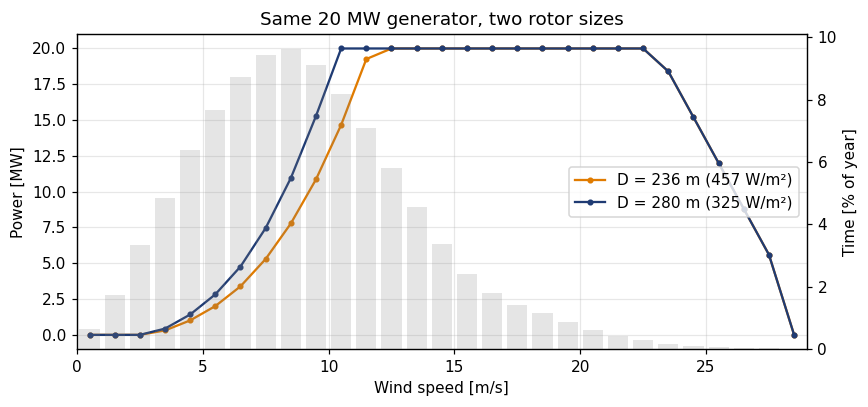

In [10]:
cp_max = df.loc[(df["v"] >= 3) & (df["v"] <= 8.5), "Cp"].max()
cp_aero = np.where(df["v"] <= 8.5, df["Cp"], cp_max)

def power_curve(D):
    Aw = np.pi * D**2 / 4
    p = np.minimum(P_rated, cp_aero * 0.5 * RHO * Aw * df["v"]**3 / 1e6)
    p = np.where(df["v"] >= 22.5, df["P_wtg"], p)         # same HWRT
    p = np.where(df["v"] < 3, 0, p)
    return p

v_fine = np.linspace(0, 28.5, 571)
res, curves = [], {}
for D in [236, 280]:
    p = power_curve(D); curves[D] = p
    E = (df["hours"] * p).sum()
    v_rated = df["v"][np.argmax(p >= 0.999 * P_rated)]
    hrs_rated = df.loc[p >= 0.999 * P_rated, "hours"].sum()
    slope = np.diff(p) / np.diff(df["v"])
    # expected |power error| for a +-1 m/s forecast error (time-weighted over the wind distribution)
    pf = lambda x: np.interp(x, np.r_[0, df["v"]], np.r_[0, p])
    err = 0.5 * (np.abs(pf(df["v"] + 1) - p) + np.abs(pf(df["v"] - 1) - p))
    exp_err = (df["time_pct"] / 100 * err).sum()
    # hourly-variability proxy: std of power over wind distribution
    mean_p = (df["time_pct"]/100*p).sum(); std_p = np.sqrt((df["time_pct"]/100*(p-mean_p)**2).sum())
    res.append({"D [m]": D, "W/m2": P_rated*1e6/(np.pi*D**2/4), "rated reached at [m/s]": v_rated,
                "AEP [MWh/yr]": E, "CF [%]": 100*E/P_rated/8760, "hours at rated [h/yr]": hrs_rated,
                "max dP/dv [MW/(m/s)]": slope.max(),
                "mean |dP| for 1 m/s forecast error [MW]": exp_err,
                "std of P / mean P [-]": std_p/mean_p})
rot = pd.DataFrame(res).set_index("D [m]").round(2)
print(f"Cp,max used = {cp_max:.3f}")
display(rot.T)

fig, ax = plt.subplots(figsize=(8, 3.8))
for D, c in zip([236, 280], ["#e07b00", "#1f3b73"]):
    ax.plot(df["v"], curves[D], "o-", ms=3, color=c, label=f"D = {D} m ({P_rated*1e6/(np.pi*D**2/4):.0f} W/m²)")
ax2 = ax.twinx(); ax2.bar(df["v"], df["time_pct"], width=0.8, alpha=0.2, color="grey", label="wind distribution")
ax2.set_ylabel("Time [% of year]"); ax2.grid(False)
ax.set_xlabel("Wind speed [m/s]"); ax.set_ylabel("Power [MW]"); ax.set_xlim(0, 29)
ax.legend(loc="center right"); ax.set_title("Same 20 MW generator, two rotor sizes")
fig.tight_layout(); fig.savefig(FIG / "p1_rotor_size_comparison.png"); plt.show()

## 8. Key numbers used in the report

In [11]:
key = {
    "time below cut-in (area I) [%]": summary.loc[0, "time share [%]"],
    "max park dP/dv [MW per m/s]": round(dPdv_park.max()),
    "max WTG dP/dv [MW per m/s]": round(dPdv.max(), 2),
    "park efficiency 14.5 m/s": round(df.loc[df.v == 14.5, "park_eff"].item(), 4),
    "park efficiency 15.5-22.5 m/s": round(df.loc[df.v == 18.5, "park_eff"].item(), 4),
    "overall wake loss [%]": round(100*(1-E_park/(N_WTG*E_wtg)), 1),
    "WTG CF [%]": round(100*E_wtg/P_rated/8760, 1),
    "park CF incl wake [%]": round(100*E_park/P_rated/8760/N_WTG, 1),
    "storm max 10-min ramp HWRT [MW]": round(ramp_soft),
    "storm max 10-min ramp hard cut-out [MW]": round(ramp_hard),
}
pd.Series(key)

time below cut-in (area I) [%]               5.7000
max park dP/dv [MW per m/s]                255.0000
max WTG dP/dv [MW per m/s]                   3.6700
park efficiency 14.5 m/s                     0.9918
park efficiency 15.5-22.5 m/s                0.9994
overall wake loss [%]                       17.7000
WTG CF [%]                                  56.4000
park CF incl wake [%]                       46.4000
storm max 10-min ramp HWRT [MW]            294.0000
storm max 10-min ramp hard cut-out [MW]    700.0000
dtype: float64